# Student Marks Prediction using Linear Regression

## Problem Statement
Predict student marks based on:
- number_courses
- time_study

## Dataset
The dataset contains study behavior and exam marks.

## 1.Importing Libraries

In [49]:
import pandas as pd
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## 2. Loading Dataset

In [50]:
df = pd.read_csv('Student_Marks.csv')

## 3. EDA

In [51]:
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [52]:
df.tail()

,number_courses,time_study,Marks
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027
99,3,6.335,32.357


In [53]:
df.columns

Index(['number_courses', 'time_study', 'Marks'], dtype='object')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [55]:
df.isnull().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

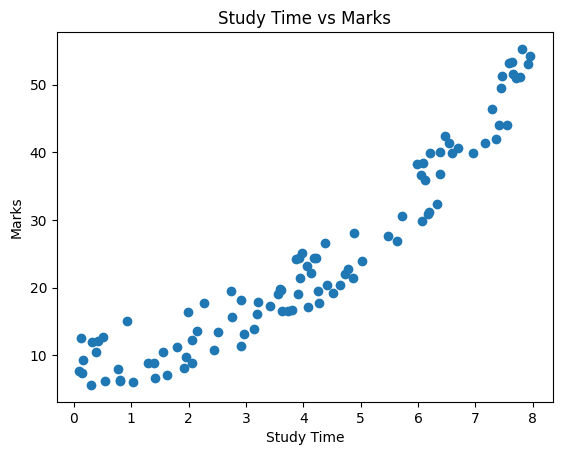

In [56]:
plt.scatter(df['time_study'], df['Marks'])
plt.xlabel("Study Time")
plt.ylabel("Marks")
plt.title("Study Time vs Marks")
plt.show()

## 4.Model Training

In [57]:
model = linear_model.LinearRegression()

In [58]:
x = df[['number_courses','time_study']]
y = df.Marks

In [59]:
scl = StandardScaler()
x = scl.fit_transform(x)

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)

In [61]:
model.fit(x_train,y_train)

LinearRegression()

In [62]:
model.intercept_

24.81083416230563

The intercept value of 24.81 represents the baseline predicted marks when all input features are zero.
It acts as the starting point of the regression model

In [63]:
model.coef_

array([ 3.48300787, 12.78857017])

Interpretation:
- Time study has higher weight in predicting marks
- Number of courses has smaller impact

## 5. Model Prediction

In [64]:
y_pred = model.predict(x_test)
y_pred

array([20.38791112, 46.41190771, 10.59625428, 23.39627891, 11.92872439,
       23.35763468, 19.47938835, 26.10309467, 31.71213255, 23.29190773,
       25.49248189,  5.89323627, 17.18746134,  6.75738058, 45.87494133,
       32.45888737, 31.11267054, 25.8539336 , 22.78566612, 40.58912166,
       23.55877526, 20.25072298, 37.28971725,  0.73741368, 15.80155418,
        3.86744838, 32.58597082, 40.93109241, 21.83162576, 37.8840804 ])

## 6.Model Evaluation

In [65]:
model.score(x_test,y_test)

0.9142328201865244

In [66]:
mean_squared_error(y_test,y_pred)

12.048794031013443

In [67]:
mean_absolute_error(y_test,y_pred)

3.047586651344028

The model achieved a Mean Absolute Error of 3.26, meaning the predicted marks differ from the actual marks by approximately 3 marks on average.
The Mean Squared Error is 12.97, indicating relatively low prediction variance.